# 1D Kalman Filter & Bayes Filter: IMU Yaw Estimation and Vehicle State Classification

**Original KF scaffold:** Andrew Q. Pham (`apham@g.hmc.edu`), 2020-02-08 — HMC ENGR205 State Estimation  
**Extended by:** Viviane Solomon (`vsolomon@g.hmc.edu`) 2024 —  HMC ENGR205 State Estimation

---

### Overview
This notebook demonstrates two probabilistic filtering techniques applied to real sensor data:

1. **1D Kalman Filter** — smooths noisy yaw angle measurements from a BNO055 IMU mounted on a ground robot.
2. **Bayes Filter (discrete)** — classifies whether each tracked vehicle in a traffic scene is stopped or moving, using NuScenes autonomous vehicle data.
3. **Bayes Filter applied to police violence data** — uses Bayes' rule to analyse conditional race probabilities given armed status and victim age.

### Data Sources
| File | Description |
|------|-------------|
| `2020-02-08_08;22;47.csv` | Stationary IMU — used to estimate sensor variance |
| `2020-02-08_08;34;45.csv` | IMU moving — trial 1 |
| `2020-02-08_08;52;01.csv` | IMU moving — trial 2 |
| `E205_Lab2_NuScenesData.xlsx` | NuScenes vehicle x/y/θ at 0.5 s intervals |
| `police_killings.csv` | Mapping Violence police killings dataset |


## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
"""
Author: Andrew Q. Pham
Email: apham@g.hmc.edu
Date of Creation: 2/8/20
Description:
    1D Kalman Filter implementation to filter logged yaw data from a BNO055 IMU
    This code is for teaching purposes for HMC ENGR205 System Simulation Lab 2
"""

import csv
import time
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

In [3]:
def load_data(filename):
    """Load in the yaw data from the csv log

    Parameters:
    filename (str)  -- the name of the csv log

    Returns:
    yaw_data (float list)   -- the logged yaw data
    """
    f = open(filename)

    file_reader = csv.reader(f, delimiter=',')

    # Load data into dictionary with headers as keys
    # Header: Latitude, Longitude, Time Stamp(ms), ...
    # ..., Yaw(degrees), Pitch(degrees), Roll(degrees)
    data = {}
    header = next(file_reader, None)
    for h in header:
        data[h] = []

    for row in file_reader:
        for h, element in zip(header, row):
            data[h].append(float(element))

    f.close()

    yaw_data = data["Yaw(degrees)"]

    return yaw_data


## Part 1 — 1D Kalman Filter for IMU Yaw

In [4]:
def prediction_step(x_t_prev, sigma_sq_t_prev):
    """Compute the prediction of 1D Kalman Filter

    Parameters:
    x_t_prev        -- the previous state estimate
    sigma_sq_t_prev -- the previous variance estimate

    Returns:
    x_bar_t         -- the predicted state estimate of time t
    sigma_sq_bar_t  -- the predicted variance estimate of time t
    """
    x_bar_t = x_t_prev
    sigma_sq_bar_t =  sigma_sq_t_prev


    return [x_bar_t, sigma_sq_bar_t]


In [5]:
def correction_step(x_bar_t, z_t, sigma_sq_bar_t, sigma_sq_z):
    """Compute the correction of 1D Kalman Filter

    Parameters:
    x_bar_t         -- the predicted state estimate of time t
    z_t             -- the measured state of time t
    sigma_sq_bar_t  -- the predicted variance of time t
    sigma_z         -- the variance of sensor measurement


    Returns:
    x_est_t         -- the filtered state estimate of time t
    sigma_sq_est_t  -- the filtered variance estimate of time t
    """
    K = (sigma_sq_bar_t) **2/( sigma_sq_bar_t + sigma_sq_z)
    x_est_t = x_bar_t + K*(z_t - x_bar_t)
    sigma_sq_est_t = sigma_sq_bar_t - K*(sigma_sq_bar_t)

    return [x_est_t, sigma_sq_est_t]

In [6]:
def wrap_to_360(angle):
    """Wrap angle data to [0, 360]"""
    return (angle + 360) % 360

In [7]:
def plot_yaw(yaw_dict, time_stamps, title=None, xlim=None, ylim=None):
    """Plot yaw data"""
    plt.plot(np.asarray(time_stamps),
             np.array(yaw_dict["measurements"]),
             '--',
             markersize=10)
    plt.plot(np.asarray(time_stamps),
             np.array(yaw_dict["estimates"]),
             '.',
             markersize=1)
    plt.plot(np.asarray(time_stamps),
             np.asarray(yaw_dict["plus_2_stddev"]),
             '.-',
             markersize=1,
             linewidth=0.5)
    plt.plot(np.asarray(time_stamps),
             np.asarray(yaw_dict["minus_2_stddev"]),
             '.-',
             markersize=1,
             linewidth=0.5)
    plt.legend(["Raw Data", "Estimate", r"+2$\sigma$", r"-2$\sigma$"])
    plt.title(title)
    plt.ylabel("Yaw (Degrees)")
    plt.xlabel("Time (s)")
    plt.xlim(xlim)
    plt.ylim(ylim)

In [8]:
testing = pd.read_csv("/content/drive/MyDrive/2020-02-08_08_22_47.csv")
testingYaw = testing["Yaw(degrees)"]
testingYaw

,Yaw(degrees)
0,99.201664
1,99.047796
2,99.842428
3,100.832418
4,97.339023
...,...
1093,100.011872
1094,100.432987
1095,99.161581
1096,96.716329


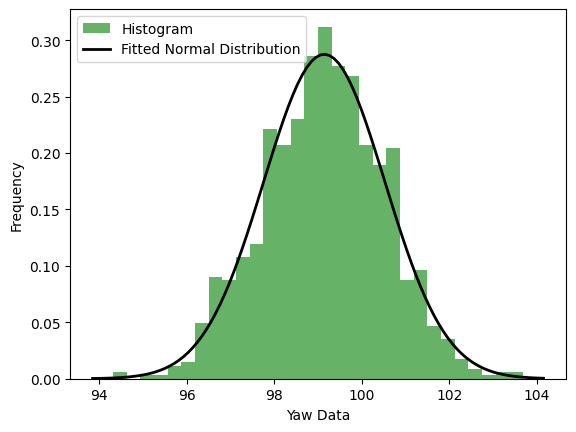

Variance of the fitted normal distribution: 1.9255394622414055


In [9]:
#Histogram of raw data
plt.hist(testingYaw, bins=30, density=True, alpha=0.6, color='g', label='Histogram')

#Fit normal distribution to data
mu, std = norm.fit(testingYaw)

#Plot PDF of fitted normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Fitted Normal Distribution')

plt.xlabel('Yaw Data')
plt.ylabel('Frequency')
plt.legend()

plt.show()

#Calculate variance associated with fitted normal distribution
variance = std**2
print(f"Variance of the fitted normal distribution: {variance}")

### 1.2 Run Kalman Filter

Toggle between trials by commenting/uncommenting the `filename` lines.

Streaming output truncated to the last 5000 lines.
Yaw State Estimate: 117.20546524838326
Yaw State Estimate: 114.85629749279029
Yaw State Estimate: 117.68280495022735
Yaw State Estimate: 118.39520276107811
Yaw State Estimate: 116.44630812550481
Yaw State Estimate: 117.92761177715867
Yaw State Estimate: 118.88232041258154
Yaw State Estimate: 117.77355390025271
Yaw State Estimate: 119.07591062934017
Yaw State Estimate: 117.21470254411831
Yaw State Estimate: 117.87522161851845
Yaw State Estimate: 117.90125032504696
Yaw State Estimate: 117.95963225240413
Yaw State Estimate: 118.84731964478149
Yaw State Estimate: 121.89075142197814
Yaw State Estimate: 115.99028491472741
Yaw State Estimate: 119.98171368799923
Yaw State Estimate: 121.2480377930682
Yaw State Estimate: 119.44218507083649
Yaw State Estimate: 119.60059569206777
Yaw State Estimate: 118.53175102052951
Yaw State Estimate: 120.46604114725281
Yaw State Estimate: 119.74191453570661
Yaw State Estimate: 119.15706085394083
Yaw State Esti

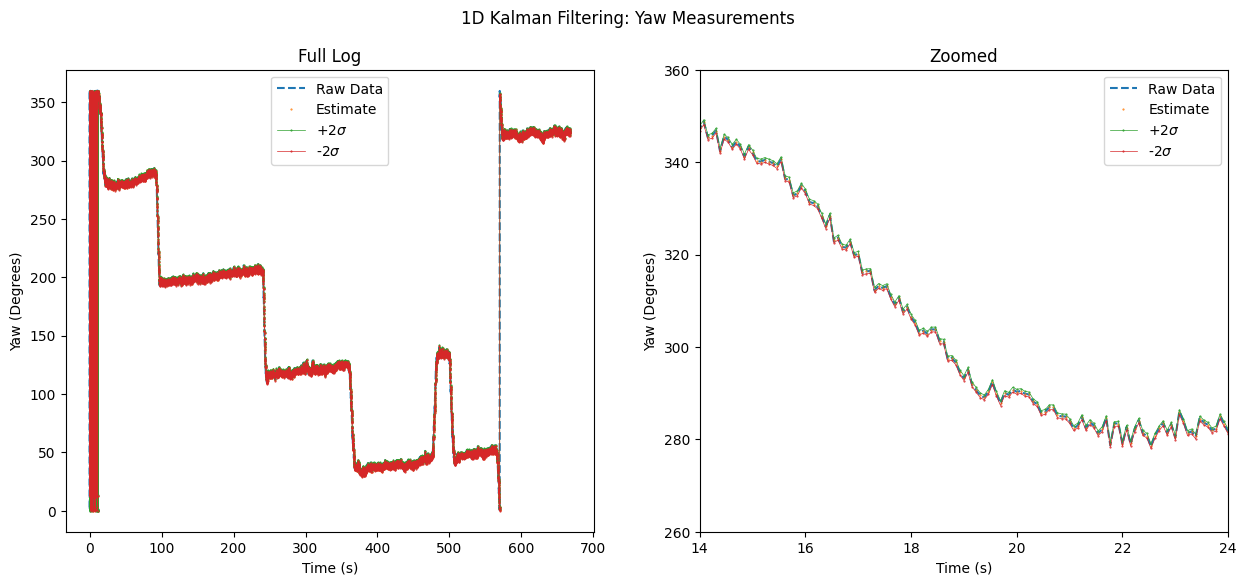

Exiting...


In [10]:
def main():
    """Run a 1D Kalman Filter on logged yaw data from a BNO055 IMU."""

    filepath = "/content/drive/MyDrive/"
    filename = "2020-02-08_08_52_01.csv"
    #filename = "2020-02-08_08_34_45.csv"
    yaw_data = load_data(filepath + filename)
    #yaw_data = load_data("/content/2020-02-08_08_34_45.csv")


    SENSOR_MODEL_VARIANCE = 1.93

    #  Initialize filter
    yaw_est_t_prev = yaw_data[0]
    var_t_prev = SENSOR_MODEL_VARIANCE
        # Initialize yaw_dict
    yaw_dict = {
        "measurements": [],
        "estimates": [],
        "plus_2_stddev": [],
        "minus_2_stddev": [],
    }
    yaw_dict["measurements"] = yaw_data
    yaw_dict["estimates"] = []
    yaw_dict["plus_2_stddev"] = []
    yaw_dict["minus_2_stddev"] = []
    time_stamps = []

    # Run filter over data
    for t, _ in enumerate(yaw_data):
        yaw_pred_t, var_pred_t = prediction_step(yaw_est_t_prev, var_t_prev)

        #getting the measurement with index 't' to show how we get a
        #new measurement each time step. To be more pythonic we could
        #replace the '_' above with 'yaw_meas'
        yaw_meas = yaw_data[t]
        var_z = SENSOR_MODEL_VARIANCE

        yaw_est_t, var_est_t = correction_step(yaw_pred_t,
                                               yaw_meas,
                                               var_pred_t,
                                               var_z)

        # Format the printouts
        sys.stdout.write("Yaw State Estimate: {0}\n\
                         \rYaw Raw Data:       {1}\
                         \033[A\r".format(yaw_est_t, yaw_meas))
        sys.stdout.flush()

        # Pause the printouts to simulate the real data rate
        dt = 1/13.  # seconds
        time_stamps.append(dt*t)

        #Comment out sleep to visualize the plot immediately
        # time.sleep(dt)

        #For clarity sake/teaching purposes, we explicitly update t->(t-1)
        yaw_est_t_prev = yaw_est_t
        var_est_t_prev = var_est_t

        #Pack data away into yaw dictionary for plotting purpose
        plus_2_stddev = wrap_to_360(yaw_est_t + 2*np.sqrt(var_est_t))
        minus_2_stddev = wrap_to_360(yaw_est_t - 2*np.sqrt(var_est_t))

        yaw_dict["estimates"].append(yaw_est_t)
        yaw_dict["plus_2_stddev"].append(plus_2_stddev)
        yaw_dict["minus_2_stddev"].append(minus_2_stddev)

    print("\n\nDone filtering...plotting...")

    #Plot raw data and estimate
    plt.figure(figsize=(15, 6))
    plt.figure(1)
    plt.suptitle("1D Kalman Filtering: Yaw Measurements")
    plt.subplot(1, 2, 1)
    plot_yaw(yaw_dict, time_stamps, title="Full Log")
    plt.subplot(1, 2, 2)
    plot_yaw(yaw_dict,
             time_stamps,
             title="Zoomed",
             xlim=[14, 24],
             ylim=[260, 360])
    plt.show()

    print("Exiting...")

    return 0


if __name__ == "__main__":
    main()

---
## Part 2 — Bayes Filter: Stopped or Not Stopped?

We classify whether each tracked vehicle is stopped at every time step using a discrete Bayes filter.

**State space:** {stopped, not stopped}  
**Observation:** instantaneous speed $s_i$ derived from Δx, Δy over 0.5 s intervals.

**Vehicle descriptions** (from scene inspection):

| Vehicle | Description |
|---------|-------------|
| Ego | Car collecting the data|
| 1 | White sedan driving in front of ego at the start of the scene|
| 2 | Black mini-SUV that turns in front of ego |
| 3 | Silver sedan that turns off street after Car 2 |
| 4 | Red SUV — **parked the entire scene, on other side of street** |
| 5 | Car behind Car 2; stops for pedestrians |
| 6 | *(to be identified — describe colour and vehicle type after watching the scene video)* |

In [11]:
import pandas as pd
cardata = pd.read_excel('/content/drive/MyDrive/E205_Lab2_NuScenesData.xlsx')

In [12]:
cardata.head()

,Time (s),X_ego,Y_ego,Yaw_ego,X_1,Y_1,Yaw_1,X_2,Y_2,Yaw_2,...,Yaw_3,X_4,Y_4,Yaw_4,X_5,Y_5,Yaw_5,X_6,Y_6,Yaw_6
0,0.0,599.849775,1647.641129,-0.500766,635.447,1620.546,-0.888442,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.5,603.568608,1645.536401,-0.518344,637.445,1618.566,-0.731363,660.000,1613.648,-1.976742,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,607.193716,1643.374074,-0.545476,639.933,1616.457,-0.696456,660.012,1613.639,-1.976742,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.5,610.730703,1641.142628,-0.574253,642.736,1614.065,-0.731363,660.025,1613.629,-1.976742,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0,614.199960,1638.821691,-0.601656,646.361,1610.980,-0.713909,660.010,1613.556,-1.976742,...,NaN,NaN,NaN,NaN,662.526,1618.552,-2.096856,NaN,NaN,NaN


### 2.1 Speed Computation Helper

In [13]:
def compute_speed(df, vehicle_id):
    """Return (speed_m_s, time_s) arrays for a given vehicle.

    Rows with NaN coordinates are excluded before differencing.
    """
    x = df[f"X_{vehicle_id}"]
    y = df[f"Y_{vehicle_id}"]
    t = df["Time (s)"]

    mask = x.notna() & y.notna() & t.notna()
    x = x[mask].to_numpy()
    y = y[mask].to_numpy()
    t = t[mask].to_numpy()

    dx = np.diff(x)
    dy = np.diff(y)
    dt = np.diff(t)

    s = np.sqrt(dx**2 + dy**2) / dt
    valid = np.isfinite(s)
    return s[valid], t[1:][valid]


### 2.2 Likelihood PDFs — p(s | stopped) and p(s | not stopped)

In [14]:
def compute_speed(cardata, i):
    x = cardata[f"X_{i}"]
    y = cardata[f"Y_{i}"]
    t = cardata["Time (s)"]

    # mask invalid rows FIRST
    mask = x.notna() & y.notna() & t.notna()
    x = x[mask].to_numpy()
    y = y[mask].to_numpy()
    t = t[mask].to_numpy()

    dx = np.diff(x)
    dy = np.diff(y)
    dt = np.diff(t)

    s = np.sqrt(dx**2 + dy**2) / dt
    return s[np.isfinite(s)]


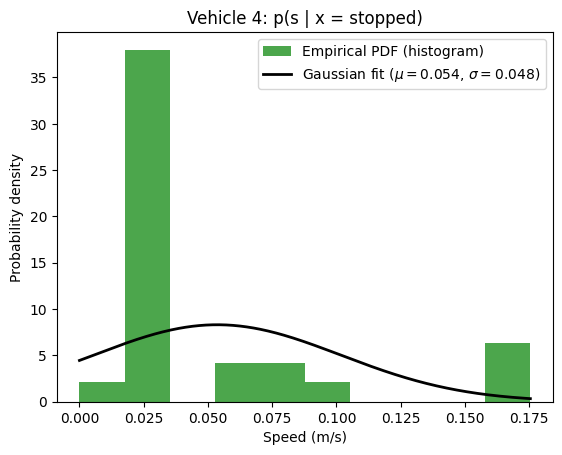

In [15]:
import numpy as np
import matplotlib.pyplot as plt

#vehicle 4 data
x4 = cardata["X_4"]
y4 = cardata["Y_4"]
t  = cardata["Time (s)"]

#mask BEFORE diff (to remove invalid data like NaN)
mask = x4.notna() & y4.notna() & t.notna()
x4 = x4[mask].to_numpy()
y4 = y4[mask].to_numpy()
t  = t[mask].to_numpy()

dx = np.diff(x4)
dy = np.diff(y4)
dt = np.diff(t)

s4 = np.sqrt(dx**2 + dy**2) / dt
s4 = s4[np.isfinite(s4)]


from scipy.stats import norm

mu, std = norm.fit(s4)

x = np.linspace(s4.min(), s4.max(), 400)
pdf = norm.pdf(x, mu, std)


plt.hist(s4, density=True, color='g', alpha = 0.7, label="Empirical PDF (histogram)")
#plt.hist(s4, label="Empirical PDF (histogram)")
plt.plot(x, pdf, 'k', linewidth=2, label=fr"Gaussian fit ($\mu={mu:.3f}$, $\sigma={std:.3f}$)")
plt.xlabel("Speed (m/s)")
plt.ylabel("Probability density")
plt.title("Vehicle 4: p(s | x = stopped)")
plt.legend()
plt.show()

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_42671/1065059130.py:37: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Vehicles 2, 3, 5: $p(s \mid x=\mathrm{not\ stopped})$")


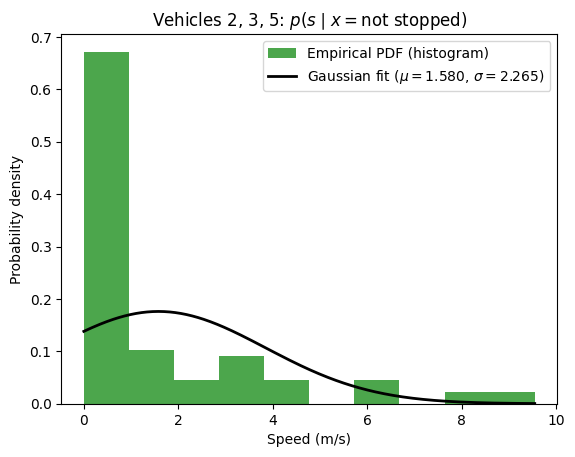

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

t = cardata["Time (s)"]

def speed_from_xy(x, y, t):
    mask = x.notna() & y.notna() & t.notna()
    x = x[mask].to_numpy()
    y = y[mask].to_numpy()
    t = t[mask].to_numpy()

    dx = np.diff(x)
    dy = np.diff(y)
    dt = np.diff(t)

    s = np.sqrt(dx**2 + dy**2) / dt
    return s[np.isfinite(s)]

s2 = speed_from_xy(cardata["X_2"], cardata["Y_2"], t)
s3 = speed_from_xy(cardata["X_3"], cardata["Y_3"], t)
s5 = speed_from_xy(cardata["X_5"], cardata["Y_5"], t)

s = np.concatenate([s2, s3, s5])

#Empirical PDF
plt.hist(s, density=True, color = 'g', alpha=0.7, label="Empirical PDF (histogram)")

#Parametric model (Gaussian)
mu, std = norm.fit(s)
xgrid = np.linspace(s.min(), s.max(), 400)
plt.plot(xgrid, norm.pdf(xgrid, mu, std), 'k', linewidth=2,
         label=fr"Gaussian fit ($\mu={mu:.3f}$, $\sigma={std:.3f}$)")

plt.xlabel("Speed (m/s)")
plt.ylabel("Probability density")
plt.title("Vehicles 2, 3, 5: $p(s \mid x=\mathrm{not\ stopped})$")
plt.legend()
plt.show()


### 2.3 Bayes Filter

**Transition model:**

| | → stopped | → not stopped |
|---|---|---|
| **from stopped** | 0.60 | 0.40 |
| **from not stopped** | 0.25 | 0.75 |


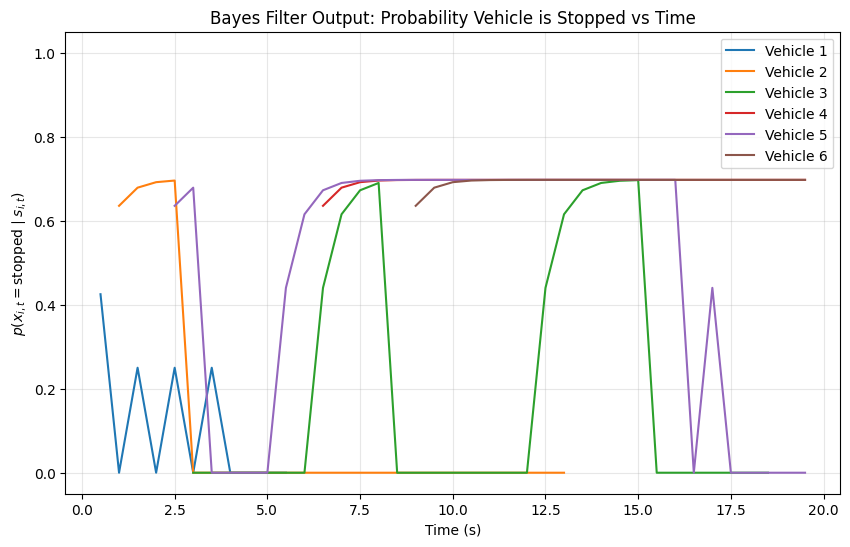

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Helper: speed from x,y,t
# -----------------------------
def speed_from_xy(x, y, t):
    mask = x.notna() & y.notna() & t.notna()
    x = x[mask].to_numpy()
    y = y[mask].to_numpy()
    t = t[mask].to_numpy()

    dx = np.diff(x)
    dy = np.diff(y)
    dt = np.diff(t)

    s = np.sqrt(dx**2 + dy**2) / dt
    s = s[np.isfinite(s)]
    return s, t[1:]  #times aligned with speed samples

# ----------------------------------------------------
# 2) Build empirical PDFs p(s | stopped) and p(s | not)
#    using shared bin edges (VERY important)
# ----------------------------------------------------
t = cardata["Time (s)"]

#stopped training data: vehicle 4
s_stop, _ = speed_from_xy(cardata["X_4"], cardata["Y_4"], t)

#not-stopped training data: vehicles 2,3,5 combined
s2, _ = speed_from_xy(cardata["X_2"], cardata["Y_2"], t)
s3, _ = speed_from_xy(cardata["X_3"], cardata["Y_3"], t)
s5, _ = speed_from_xy(cardata["X_5"], cardata["Y_5"], t)
s_not = np.concatenate([s2, s3, s5])

#choosing common bins covering both distributions
s_all = np.concatenate([s_stop, s_not])
bins = np.linspace(s_all.min(), s_all.max(), 31)   #30 bins - can be adjusted

#histogram density estimates (area ~ 1)
p_stop_hist, edges = np.histogram(s_stop, bins=bins, density=True)
p_not_hist,  _     = np.histogram(s_not,  bins=bins, density=True)

bin_width = edges[1] - edges[0]
eps = 1e-6  #floor to avoid exact zeros

def pdf_from_hist(s, hist, edges):
    """Return p(s) by looking up which bin s falls in."""
    idx = np.searchsorted(edges, s, side="right") - 1
    idx = np.clip(idx, 0, len(hist) - 1)
    return np.maximum(hist[idx], eps)

# -----------------------------------------
# 3) Bayes filter (part d) for one vehicle
# -----------------------------------------
def bayes_filter_stopped_prob(s_meas, pS0=0.5):
    #Transition model (given)
    pSS = 0.6
    pNS = 0.4
    pSN = 0.25
    pNN = 0.75

    pS = pS0
    out = np.zeros_like(s_meas, dtype=float)

    for k, s in enumerate(s_meas):
        #Prediction
        pS_bar = pSS*pS + pSN*(1 - pS)
        pN_bar = pNS*pS + pNN*(1 - pS)

        #Measurement likelihoods
        likeS = pdf_from_hist(s, p_stop_hist, edges)
        likeN = pdf_from_hist(s, p_not_hist,  edges)

        #Update + normalize
        numS = likeS * pS_bar
        numN = likeN * pN_bar
        pS = numS / (numS + numN)

        out[k] = pS

    return out

# -------------------------------------------------------
# 4) Run filter for ALL vehicles and plot (part e)
#    Adjust vehicle list to match your spreadsheet columns
# -------------------------------------------------------
vehicle_ids = [1, 2, 3, 4, 5, 6]  #change if ego also as separate column

plt.figure(figsize=(10, 6))
for vid in vehicle_ids:
    s, t_s = speed_from_xy(cardata[f"X_{vid}"], cardata[f"Y_{vid}"], t)
    pS = bayes_filter_stopped_prob(s, pS0=0.5)
    plt.plot(t_s, pS, label=f"Vehicle {vid}")

plt.xlabel("Time (s)")
plt.ylabel(r"$p(x_{i,t}=\mathrm{stopped}\mid s_{i,t})$")
plt.title("Bayes Filter Output: Probability Vehicle is Stopped vs Time")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


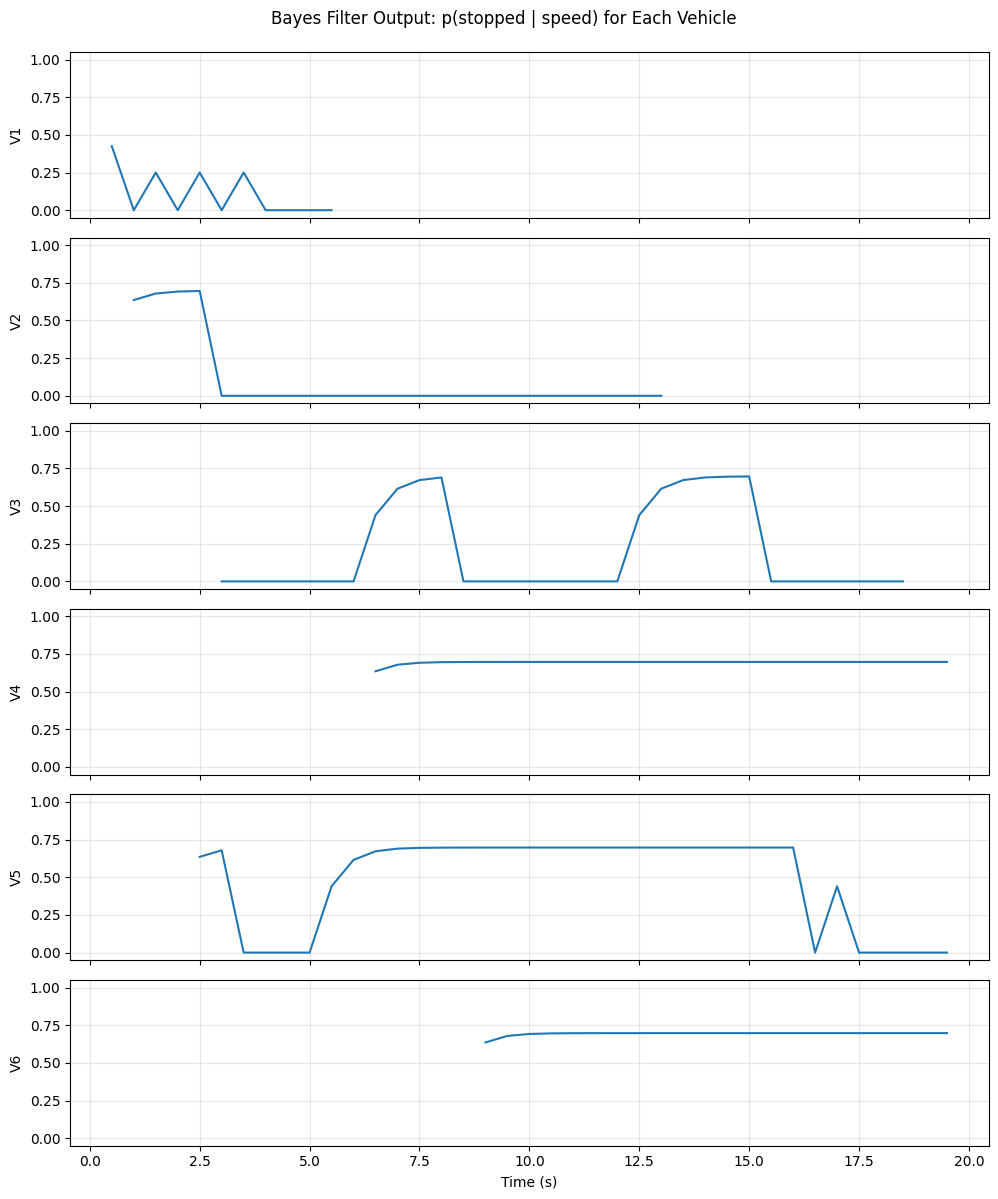

In [18]:
vehicle_ids = [1, 2, 3, 4, 5, 6]

fig, axs = plt.subplots(len(vehicle_ids), 1, figsize=(10, 12), sharex=True)

for ax, vid in zip(axs, vehicle_ids):
    s, t_s = speed_from_xy(cardata[f"X_{vid}"], cardata[f"Y_{vid}"], t)
    pS = bayes_filter_stopped_prob(s, pS0=0.5)

    ax.plot(t_s, pS)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(f"V{vid}")

axs[-1].set_xlabel("Time (s)")
fig.suptitle("Bayes Filter Output: p(stopped | speed) for Each Vehicle", y=0.995)
plt.tight_layout()
plt.show()


---
## Part 3 — Bayes Filter Applied to Police Violence Data

Using Bayes' rule to analyse conditional race distributions in a police killings dataset,
conditioned on (a) armed status and (b) victim age.

> **Note:** All probabilities are empirical frequencies computed from the dataset
> and should be interpreted as descriptive statistics, not causal claims.


In [19]:
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/police_killings.csv"
df = pd.read_csv(file_path)

In [20]:
df
victim_race = df["Victim's race"]
victim_armed = df['Unarmed']

In [21]:
victim_armed

,Unarmed
0,Allegedly Armed
1,Unclear
2,Allegedly Armed
3,Allegedly Armed
4,Vehicle
...,...
7902,NaN
7903,NaN
7904,NaN
7905,NaN


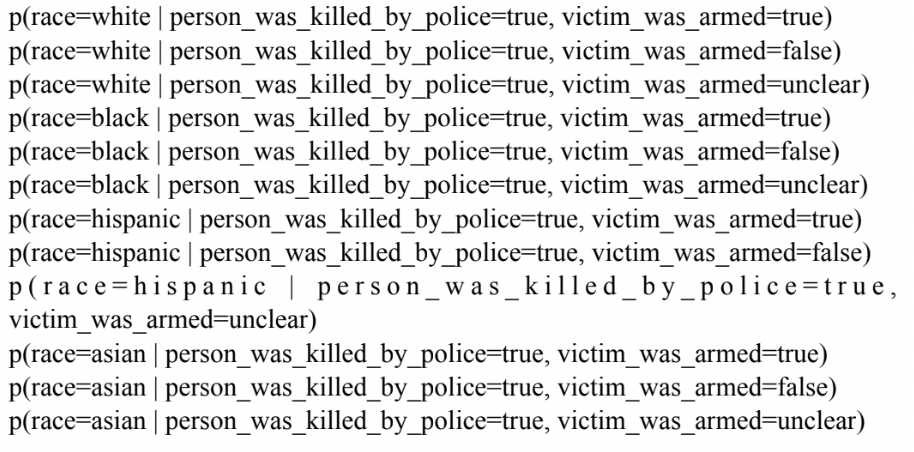

In [22]:
races4 = ["White", "Black", "Hispanic", "Asian"]
armed_states = ["Armed", "Unarmed", "Unclear"]

df["Unarmed"] = df["Unarmed"].replace({
    "Allegedly Armed": "Armed"
})

for a in armed_states:
    sub = df[df["Unarmed"].eq(a) & df["Victim's race"].isin(races4)]
    denom = len(sub)

    print(f"\nArmed status = {a} (N={denom})")
    for r in races4:
        p = (sub["Victim's race"].eq(r).sum() / denom) if denom > 0 else float("nan")
        print(f"  P(race={r} | armed={a}) = {p:.4f}")

    total = sum((sub["Victim's race"].eq(r).sum() / denom) for r in races4) if denom > 0 else float("nan")
    print(f"  Sum over 4 races = {total:.4f}")




Armed status = Armed (N=4769)
  P(race=White | armed=Armed) = 0.5169
  P(race=Black | armed=Armed) = 0.2739
  P(race=Hispanic | armed=Armed) = 0.1898
  P(race=Asian | armed=Armed) = 0.0195
  Sum over 4 races = 1.0000

Armed status = Unarmed (N=1001)
  P(race=White | armed=Unarmed) = 0.4515
  P(race=Black | armed=Unarmed) = 0.3357
  P(race=Hispanic | armed=Unarmed) = 0.2008
  P(race=Asian | armed=Unarmed) = 0.0120
  Sum over 4 races = 1.0000

Armed status = Unclear (N=542)
  P(race=White | armed=Unclear) = 0.4594
  P(race=Black | armed=Unclear) = 0.2804
  P(race=Hispanic | armed=Unclear) = 0.2435
  P(race=Asian | armed=Unclear) = 0.0166
  Sum over 4 races = 1.0000


**calculate predicted probabilities for different races, for the two specific cases:** <br>
a) p(victim_was_armed = true) = 0.8, p(victim_was_armed = unclear) = 0.2 <br>

b) p(victim_was_armed = false) = 0.8, p(victim_was_armed = unclear) = 0.2

Probability rule: To predict the race distribution, average over the possible armed states, weighted by how likely each armed state is.

In [23]:
# Case (a)
p_armed_case_a = {
    "Armed": 0.8,
    "Unclear": 0.2
}

# Case (b)
p_armed_case_b = {
    "Unarmed": 0.8,
    "Unclear": 0.2
}


In [24]:
P_race_given_armed = {
    "White": {
        "Armed": 0.5150,
        "Unarmed": 0.4511,
        "Unclear": 0.4598
    },
    "Black": {
        "Armed": 0.2788,
        "Unarmed": 0.3370,
        "Unclear": 0.2804
    },
    "Hispanic": {
        "Armed": 0.1875,
        "Unarmed": 0.1998,
        "Unclear": 0.2430
    },
    "Asian": {
        "Armed": 0.0188,
        "Unarmed": 0.0121,
        "Unclear": 0.0168
    }
}


### 3b & 3c — Conditional Probabilities and Prediction Step

In [25]:
def predicted_race_probs(P_race_given_armed, p_armed_case):
    results = {}

    for race in P_race_given_armed:
        total = 0.0
        for armed_state, p_armed in p_armed_case.items():
            p_race_given_state = P_race_given_armed[race].get(armed_state, 0)
            total += p_race_given_state * p_armed

        results[race] = total

    return results


In [26]:
import numpy as np
import pandas as pd

# ----------------------------
# Part (c): Prediction step using the probability rule
# ----------------------------

#categories
races4 = ["White", "Black", "Hispanic", "Asian"]
armed_states = ["Armed", "Unarmed", "Unclear"]

# --- 1) Ensuree armed labels match model ---
df = df.copy()
df["Unarmed"] = df["Unarmed"].replace({"Allegedly Armed": "Armed"})

# --- 2) Compute empirical conditional probabilities from the dataset:
#       p(race=i | pwkby=true, armed=j)  (restricted to the 4 races, renormalized within each armed state)
cond = pd.DataFrame(index=races4, columns=armed_states, dtype=float)

for a in armed_states:
    sub = df[df["Unarmed"].eq(a) & df["Victim's race"].isin(races4)]
    denom = len(sub)
    for r in races4:
        cond.loc[r, a] = (sub["Victim's race"].eq(r).sum() / denom) if denom > 0 else np.nan

print("Conditional probabilities from part (b) (renormalized over 4 races):")
print(cond.round(4))
print("\nColumn sums (should be ~1.0):")
print(cond.sum(axis=0).round(4))

# --- 3) Two provided armed-status priors for the prediction step ---
# Case (a): p(armed)=0.8, p(unclear)=0.2, p(unarmed)=0
w_case_a = {"Armed": 0.8, "Unarmed": 0.0, "Unclear": 0.2}

# Case (b): p(unarmed)=0.8, p(unclear)=0.2, p(armed)=0
w_case_b = {"Armed": 0.0, "Unarmed": 0.8, "Unclear": 0.2}

def predict_race_distribution(cond_table, weights_dict):
    """Compute predicted p(race | pwkby=true) using the law of total probability."""
    pred = {}
    for r in cond_table.index:
        pred[r] = sum(cond_table.loc[r, a] * weights_dict.get(a, 0.0) for a in cond_table.columns)
    # Renormalize to fix small floating-point / rounding drift
    total = sum(pred.values())
    if np.isfinite(total) and total > 0:
        pred = {r: p / total for r, p in pred.items()}
    return pred

# --- 4) Compute predictions for both cases ---
pred_a = predict_race_distribution(cond, w_case_a)
pred_b = predict_race_distribution(cond, w_case_b)

# --- 5) Put into table ---
pred_df = pd.DataFrame({
    "Case (a): p(armed)=0.8, p(unclear)=0.2": pd.Series(pred_a),
    "Case (b): p(unarmed)=0.8, p(unclear)=0.2": pd.Series(pred_b),
}).reindex(races4)

print("\nPredicted race probabilities (Part c):")
print(pred_df.round(4))

print("\nRow sums (each column should sum to 1.0):")
print(pred_df.sum(axis=0).round(6))


Conditional probabilities from part (b) (renormalized over 4 races):
           Armed  Unarmed  Unclear
White     0.5169   0.4515   0.4594
Black     0.2739   0.3357   0.2804
Hispanic  0.1898   0.2008   0.2435
Asian     0.0195   0.0120   0.0166

Column sums (should be ~1.0):
Armed      1.0
Unarmed    1.0
Unclear    1.0
dtype: float64

Predicted race probabilities (Part c):
          Case (a): p(armed)=0.8, p(unclear)=0.2  \
White                                     0.5054   
Black                                     0.2752   
Hispanic                                  0.2005   
Asian                                     0.0189   

          Case (b): p(unarmed)=0.8, p(unclear)=0.2  
White                                       0.4531  
Black                                       0.3246  
Hispanic                                    0.2093  
Asian                                       0.0129  

Row sums (each column should sum to 1.0):
Case (a): p(armed)=0.8, p(unclear)=0.2      1.0
Case (b)

In [27]:
import numpy as np
import pandas as pd

RACE_COL = "Victim's race"
AGE_COL  = "Victim's age"

races = ["White", "Black", "Hispanic", "Asian"]

# ---------- 1) Clean / coerce age ----------
#Make sure age is numeric (fixes the "str vs int" issue you hit earlier)
df = df.copy()
df[AGE_COL] = pd.to_numeric(df[AGE_COL], errors="coerce")
df = df[df[AGE_COL].notna()]
df = df[df[AGE_COL] > 0]  # remove invalid ages

#Keep only the races required by the lab
df = df[df[RACE_COL].isin(races)]

#Evidence event: age < 20
is_u20 = df[AGE_COL] < 20

# ---------- 2) Compute likelihoods p(age<20 | race=i, pwkby=true) ----------
#Since this dataset is police killings, pwkby=true is implicitly satisfied by all rows.
likelihood = {}
for r in races:
    sub = df[df[RACE_COL] == r]
    denom = len(sub)
    likelihood[r] = ( (sub[AGE_COL] < 20).sum() / denom ) if denom > 0 else np.nan

# ---------- 3) Prior p(race=i | pwkby=true) ----------
prior = {
    "White": 0.589,
    "Black": 0.136,
    "Hispanic": 0.191,
    "Asian": 0.063
}

#Sanity check: priors should sum ~ 1
print("Prior sum:", sum(prior.values()))

# ---------- 4) Posterior via Bayes rule ----------
#Unnormalized posterior: p(age<20 | race=i) * p(race=i)
unnorm = {r: likelihood[r] * prior[r] for r in races}

eta = 1.0 / sum(unnorm.values())  # normalization factor
posterior = {r: eta * unnorm[r] for r in races}

# ---------- 5) Output a clean table for your report ----------
table_d = pd.DataFrame({
    "Race (i)": races,
    "p(age<20 | race=i, pwkby=true)": [likelihood[r] for r in races],
    "Prior p(race=i | pwkby=true)": [prior[r] for r in races],
    "Unnormalized": [unnorm[r] for r in races],
    "Posterior p(race=i | pwkby=true, age<20)": [posterior[r] for r in races],
})

#Round for reporting
print("\nPart (d) results:")
print(table_d.round(4))

print("\nNormalization factor eta =", round(eta, 4))


Prior sum: 0.979

Part (d) results:
   Race (i)  p(age<20 | race=i, pwkby=true)  Prior p(race=i | pwkby=true)  \
0     White                          0.0313                         0.589   
1     Black                          0.0888                         0.136   
2  Hispanic                          0.0740                         0.191   
3     Asian                          0.0508                         0.063   

   Unnormalized  Posterior p(race=i | pwkby=true, age<20)  
0        0.0184                                    0.3852  
1        0.0121                                    0.2524  
2        0.0141                                    0.2954  
3        0.0032                                    0.0669  

Normalization factor eta = 20.8963


In [28]:
import numpy as np
import pandas as pd

# ----------------------------
# Part (d): Correction step (Bayes update) using age < 20
# Goal: compute p(race=i | pwkby=true, age<20)
# ----------------------------

races4 = ["White", "Black", "Hispanic", "Asian"]
RACE_COL = "Victim's race"
AGE_COL  = "Victim's age"

df = df.copy()

# --- 1) Ensure age is numeric and valid ---
df[AGE_COL] = pd.to_numeric(df[AGE_COL], errors="coerce")   # convert strings -> numbers; invalid -> NaN
df = df[df[AGE_COL].notna()]                                # drop missing ages
df = df[df[AGE_COL] > 0]                                    # remove invalid/non-positive ages

#Keep only the four race states used in the model
df4 = df[df[RACE_COL].isin(races4)].copy()

#Evidence event: victim age < 20
evidence = df4[AGE_COL] < 20

# --- 2) Likelihoods from dataset: p(age<20 | pwkby=true, race=i) ---
likelihood = {}
counts = {}
for r in races4:
    sub = df4[df4[RACE_COL].eq(r)]
    denom = len(sub)
    num = (sub[AGE_COL] < 20).sum()
    counts[r] = {"N_race": denom, "N_age_lt_20": num}
    likelihood[r] = (num / denom) if denom > 0 else np.nan

likelihood_s = pd.Series(likelihood, name="p(age<20 | race)")

# --- 3) Prior p(race=i | pwkby=true) ---
#Using Google/census priors from part (a)
prior = pd.Series({
    "White": 0.589,
    "Black": 0.136,
    "Hispanic": 0.191,
    "Asian": 0.063
}, name="prior p(race)")

#Renormalize prior over the 4 races in case of tiny rounding drift
prior = prior / prior.sum()

# --- 4) Bayes rule update (unnormalized posterior) ---
unnorm = likelihood_s * prior

#Normalization factor eta so posterior sums to 1
eta = 1.0 / unnorm.sum()

posterior = (eta * unnorm).rename("posterior p(race | age<20)")

# --- 5) Output a report-ready table (includes counts for transparency) ---
out = pd.DataFrame({
    "N (race)": [counts[r]["N_race"] for r in races4],
    "N (age<20 within race)": [counts[r]["N_age_lt_20"] for r in races4],
    "p(age<20 | race)": likelihood_s.values,
    "prior p(race)": prior.values,
    "unnormalized": unnorm.values,
    "posterior p(race | age<20)": posterior.values
}, index=races4)

print("Part (d) Bayes update results:")
print(out.round(4))
print("\nNormalization factor eta =", round(eta, 6))
print("Posterior sum =", round(posterior.sum(), 6))


Part (d) Bayes update results:
          N (race)  N (age<20 within race)  p(age<20 | race)  prior p(race)  \
White         3355                     105            0.0313         0.6016   
Black         1925                     171            0.0888         0.1389   
Hispanic      1297                      96            0.0740         0.1951   
Asian          118                       6            0.0508         0.0644   

          unnormalized  posterior p(race | age<20)  
White           0.0188                      0.3852  
Black           0.0123                      0.2524  
Hispanic        0.0144                      0.2954  
Asian           0.0033                      0.0669  

Normalization factor eta = 20.457483
Posterior sum = 1.0
